<table>
    <tr>
      <td>Minería de Datos y Paradigma BigData (<b>MIN</b>) - Facultad de Informática - UCM</td>
      <td><img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg" width=50/></td>
    </tr>
</table>

# Machine Learning, regresión lineal: precios de pisos en Madrid

En este notebook construiremos modelos de regresión para predecir el **precio** de viviendas a partir de un dataset en Excel (`precios_pisos_madrid.xlsx`).

**Ideas clave**
- Carga y exploración del dataset (EDA).
- Preprocesamiento del dataset.
- Entrenamiento de modelos base y modelos extendidos (Ridge, RandomForest).
- Comparación con métricas (MAE, RMSE, R²) y diagnóstico de residuos (para el modelo lineal).

## Índice

1. [Configuración inicial](#Configuración-inicial)
2. [Carga del dataset](#Carga-del-dataset)
3. [Exploración rápida (EDA)](#Exploración-rápida-EDA)
4. [Limpieza y *feature engineering*](#Limpieza-y-feature-engineering)
   - [Extracción de zona a partir del título](#Extracción-de-zona-a-partir-del-título)
   - [Selección de variables y fuga de información](#Selección-de-variables-y-fuga-de-información)
5. [Preprocesado con `ColumnTransformer`](#Preprocesado-con-ColumnTransformer)
6. [Modelos y evaluación](#Modelos-y-evaluación)
   - [Baseline](#Baseline)
   - [Ridge (modelo lineal)](#Ridge-modelo-lineal)
   - [Random Forest](#Random-Forest)
   - [Comparación](#Comparación)
7. [Interpretabilidad](#Interpretabilidad)
8. [Diagnóstico de residuos (modelo lineal)](#Diagnóstico-de-residuos-modelo-lineal)
9. [Predicción de un nuevo ejemplo](#Predicción-de-un-nuevo-ejemplo)
10. [Ejercicios propuestos](#Ejercicios-propuestos)


## Configuración inicial

Importamos las librerías y fijamos algunas opciones para que la salida sea legible.


In [2]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.inspection import permutation_importance

# (Opcional) tests estadísticos para residuos del modelo lineal
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

RANDOM_STATE = 42


---
## Carga del dataset

El dataset está en Excel. Para ejecutar este notebook en tu máquina, coloca `precios_pisos_madrid.xlsx` en la misma carpeta del notebook, o actualiza la ruta en `DATA_PATH`.


In [3]:
from pathlib import Path

DATA_PATH = Path("precios_pisos_madrid.xlsx")  # ajusta si lo tienes en otra carpeta

df_raw = pd.read_excel(DATA_PATH)
print("Shape (filas, columnas):", df_raw.shape)
df_raw.head()


Shape (filas, columnas): (2844, 37)


,url,titulo,referencia,precio,precio_num,superficie_m2,habitaciones,banos,estado,calificacion_energetica,tour_virtual,telefono,precio_por_m2,fecha_extraccion,datos_completos,visitado_fecha,metros_utiles,estado_detallado,ascensor,aire_acondicionado,calefaccion,tipo_suelo,antiguedad,anio_construccion,numero_terrazas,parking,trastero,tiene_terraza,balcon,jardin,piscina,amueblado,cocina_equipada,agua_caliente,orientacion,tipo_fachada,garajes
0,https://www.redpiso.es/inmueble/piso-en-venta-...,"Piso en venta en CALLE VEREDA DEL PRADO, Ciemp...",RP1972024125050,115.000 €,115000.0,88.0,3.0,1.0,RESERVADO,E,True,telefono1,1306.82,2026-01-30 22:18:10,True,2026-01-30 23:40:04,70.0,Perfecto Estado,True,True,Eléctrica,Terrazo,Entre 35 y 50 Años,1978.0,1.0,False,False,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,https://www.redpiso.es/inmueble/piso-en-venta-...,"Piso en venta en Villaverde, Madrid, Madrid",RP472026145978,148.000 €,148000.0,38.0,1.0,1.0,DISPONIBLE,F,True,telefono2,3894.74,2026-01-30 22:18:10,True,2026-01-30 23:40:35,NaN,NaN,True,False,NaN,Gres,NaN,1980.0,NaN,False,False,False,False,False,False,False,False,NaN,NaN,NaN,NaN
2,https://www.redpiso.es/inmueble/piso-en-venta-...,"Piso en venta en Alcorcón, Madrid",RP1692024122535,159.000 €,159000.0,68.0,3.0,1.0,RESERVADO,F,True,telefono3,2338.24,2026-01-30 22:18:10,True,2026-01-30 23:41:09,63.0,Depende del precio,False,False,Gas Natural,Baldosa,Más de 50 años,1950.0,1.0,False,False,False,False,False,False,False,False,Gas natural,NaN,NaN,NaN
3,https://www.redpiso.es/inmueble/piso-en-venta-...,"Piso en venta en La Fortuna, Leganés, Madrid",RP1312025142220,164.900 €,164900.0,50.0,2.0,1.0,DISPONIBLE,G,True,telefono4,3298.00,2026-01-30 22:18:10,True,2026-01-30 23:41:18,41.0,Perfecto Estado,False,False,Eléctrica,Gres,NaN,NaN,NaN,False,False,False,False,False,False,False,False,Individual,Sureste,NaN,NaN
4,https://www.redpiso.es/inmueble/piso-en-venta-...,"Piso en venta en San Blas-Canillejas, Madrid, ...",RP492026145360,172.260 €,172260.0,57.0,3.0,1.0,DISPONIBLE,G,True,telefono5,3022.11,2026-01-30 22:18:10,True,2026-01-30 23:41:50,NaN,A reformar,False,True,NaN,Tarima normal,Entre 35 y 50 Años,NaN,NaN,False,False,False,False,False,False,False,True,NaN,NaN,Ladrillo,NaN


### Columnas principales

- `precio_num`: **objetivo** (precio en euros).
- `superficie_m2`, `habitaciones`, `banos`, etc.: variables numéricas.
- Muchas variables binarias (booleanas): `ascensor`, `aire_acondicionado`, `parking`, etc.
- Variables categóricas: `calificacion_energetica`, `tipo_suelo`, `calefaccion`, etc.
- Columnas tipo identificador/ruido: `url`, `referencia`, `telefono`.


--
## Exploración rápida (EDA)

Miramos tipos, valores nulos, duplicados y una descripción estadística básica.


In [4]:
df = df_raw.copy()

display(df.dtypes)


url                         object
titulo                      object
referencia                  object
precio                      object
precio_num                 float64
superficie_m2              float64
habitaciones               float64
banos                      float64
estado                      object
calificacion_energetica     object
tour_virtual                  bool
telefono                    object
precio_por_m2              float64
fecha_extraccion            object
datos_completos               bool
visitado_fecha              object
metros_utiles              float64
estado_detallado            object
ascensor                      bool
aire_acondicionado            bool
calefaccion                 object
tipo_suelo                  object
antiguedad                  object
anio_construccion          float64
numero_terrazas            float64
parking                       bool
trastero                      bool
tiene_terraza                 bool
balcon              

In [5]:
# Nulos por columna (top 15)
nulls = df.isna().sum().sort_values(ascending=False)
display(nulls.head(15).to_frame("nulos"))


,nulos
garajes,2154
numero_terrazas,1513
orientacion,1443
tipo_fachada,1185
calificacion_energetica,1145
agua_caliente,757
metros_utiles,734
anio_construccion,608
estado_detallado,561
calefaccion,487


In [5]:
# Duplicados exactos (todas las columnas)
print("Duplicados exactos:", df.duplicated().sum())


Duplicados exactos: 0


In [6]:
# Estadísticos básicos de las numéricas
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
precio_num,2380.0,338576.863025,281690.634339,40000.00,198000.000,264128.50,375000.000,6600000.00
superficie_m2,2836.0,86.322285,35.439859,23.00,65.000,80.00,100.000,672.00
habitaciones,2838.0,2.664905,0.833373,1.00,2.000,3.00,3.000,8.00
banos,2833.0,1.381574,0.564523,1.00,1.000,1.00,2.000,6.00
precio_por_m2,2375.0,3871.186463,1862.401312,632.18,2638.465,3368.75,4565.185,18424.66
metros_utiles,2110.0,73.882938,27.614137,1.00,57.250,70.00,85.000,478.00
anio_construccion,2236.0,1971.987030,24.726428,1860.00,1962.000,1971.00,1987.000,2028.00
numero_terrazas,1331.0,1.226897,0.460040,1.00,1.000,1.00,1.000,4.00
garajes,690.0,1.153623,0.364849,1.00,1.000,1.00,1.000,3.00


---
## Limpieza y feature engineering

### 1) Filtrado de filas sin objetivo

Si `precio_num` es nulo, no podemos entrenar un modelo supervisado: eliminamos esas filas.


In [7]:
df = df.dropna(subset=["precio_num"]).copy()
print("Shape tras dropna(precio_num):", df.shape)


Shape tras dropna(precio_num): (2380, 37)


### 2) Normalización de tipos

- Convertimos fechas a `datetime` (si aparecen como texto).
- Convertimos booleanos a `0/1` (enteros) para facilitar pipelines.

Recordatorio: 
- Las fechas se convierten con `pd.to_datetime(df['nombre_columna'], errors="coerce")`.
- Las columnas se convierten con `df_copia= df["nombre_columna"].astype("tipo")`

In [1]:
# Parseo de fechas (si existen)
for col in ["fecha_extraccion", "visitado_fecha"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Booleanos -> Int64 (0/1 con soporte de NA)
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
for c in bool_cols:
    df[c] = df[c].astype("Int64")

print("Booleanos convertidos:", bool_cols)


NameError: name 'df' is not defined

### Extracción de zona a partir del título

`titulo` suele contener ubicación (barrio/distrito/municipio), pero como texto libre tiene mucha cardinalidad.

La idea: **extraer la zona** (p.ej. `Leganés`, `Zarzaquemada`) a partir del título y usarlo como categórica.

> Esto es un ejemplo típico de *feature engineering* sencillo pero útil: conviertes un texto ruidoso en categorías manejables.

Recordatorio:
- Utiliza split para partir las cadenas
- Las expresiones regulares siguen el siguiente formato `re.match(r"^CADENA", string_donde_busco, flags=re.IGNORECASE)`


In [9]:
def extraer_zonas(titulo):
    zonaRet1 = None
    zonaRet2 = None
    
    #Eliminamos "piso en venta en"
    titulo = titulo.replace("Piso en venta en ", "")
    
    #Partimos separados por comas 
    zonas = titulo.split(",")
    #si el numero de partes es mayor o igual que 2, procedemos a buscar
    if len(zonas) >= 2:
        #Si la primera parte tiene "CALLE|AVENIDA|PLAZA|PASEO|C\.|AV\.|CTRA|CARRETERA", la descartamos
        if re.match(r"^(CALLE|AVENIDA|PLAZA|PASEO|C\.|AV\.|CTRA|CARRETERA)\b", zonas[0], flags=re.IGNORECASE):
            zonas = zonas[1:]

        #Eliminamos las apariciones de "Madrid", porque son pisos en Madrid
        zonas = [z for z in zonas if z.strip().lower() != "madrid"]

        #Ahora, si tenemos un array con 2 elementos, tomamos las dos zonas
        if len(zonas)>1:
            zonaRet1= zonas[-1]
            zonaRet2= zonas[-2]
        #Si solo tenemos 1, la segunda zona se queda en NULL    
        elif len(zonas)==1:
            zonaRet1 = zonas[0]
        
    return (zonaRet1, zonaRet2)
    
df[["zona_1", "zona_2"]] = df["titulo"].apply(lambda t: pd.Series(extraer_zonas(t)))
print(df)

                                                    url                                             titulo       referencia       precio  \
0     https://www.redpiso.es/inmueble/piso-en-venta-...  Piso en venta en CALLE VEREDA DEL PRADO, Ciemp...  RP1972024125050    115.000 €   
1     https://www.redpiso.es/inmueble/piso-en-venta-...        Piso en venta en Villaverde, Madrid, Madrid   RP472026145978    148.000 €   
2     https://www.redpiso.es/inmueble/piso-en-venta-...                  Piso en venta en Alcorcón, Madrid  RP1692024122535    159.000 €   
3     https://www.redpiso.es/inmueble/piso-en-venta-...       Piso en venta en La Fortuna, Leganés, Madrid  RP1312025142220    164.900 €   
4     https://www.redpiso.es/inmueble/piso-en-venta-...  Piso en venta en San Blas-Canillejas, Madrid, ...   RP492026145360    172.260 €   
...                                                 ...                                                ...              ...          ...   
2662  https://www.re

### Variables de fecha

En vez de usar `fecha_extraccion`/`visitado_fecha` como texto, extraemos componentes sencillos (año, mes, día de la semana).


In [10]:
def expandir_fecha(df_in: pd.DataFrame, col: str):
    if col not in df_in.columns:
        return df_in
    dt = df_in[col]
    df_in[f"{col}_year"] = dt.dt.year
    df_in[f"{col}_month"] = dt.dt.month
    df_in[f"{col}_dow"] = dt.dt.dayofweek
    return df_in.drop(columns=[col])

for col in ["fecha_extraccion", "visitado_fecha"]:
    df = expandir_fecha(df, col)

df.filter(regex=r"fecha|visitado").head()


,fecha_extraccion_year,fecha_extraccion_month,fecha_extraccion_dow,visitado_fecha_year,visitado_fecha_month,visitado_fecha_dow
0,2026,1,4,2026,1,4
1,2026,1,4,2026,1,4
2,2026,1,4,2026,1,4
3,2026,1,4,2026,1,4
4,2026,1,4,2026,1,4


### Selección de variables y fuga de información

Elegimos `precio_num` como variable objetivo.

**Columnas que NO usaremos como features**
Determina que variables deben ser descartadas para predecir el precio

No deberán ser utilizadas:
- Identificadores/URLs: `url`, `referencia`, `telefono`.
- Texto libre completo: `titulo` (usamos `zona_1` y `zona_2` en su lugar).
- `precio` (string) y `precio_num` (objetivo).


A continuación, descarta las columnas que consideres, y ademas, cambia el tipo de las variables detectadas como bool, a Int64.

In [11]:
TARGET = "precio_num"

drop_ids = ["url", "referencia", "telefono", "titulo", "precio", TARGET]

# Dos configuraciones: con leakage y sin leakage
LEAKY_FEATURES = []  # incluye precio_por_m2 (si existe)
CLEAN_EXTRA_DROP = ["precio_por_m2"]  # lo quitamos para escenario "sin fuga"

def construir_X(df_in: pd.DataFrame, extra_drop=None):
    extra_drop = extra_drop or []
    cols_to_drop = [c for c in drop_ids + extra_drop if c in df_in.columns]
    X = df_in.drop(columns=cols_to_drop).copy()

    # Aseguramos bool->Int64 por si reaparece algún bool
    for c in X.select_dtypes(include=["bool"]).columns:
        X[c] = X[c].astype("Int64")

    return X

X_leaky = construir_X(df, extra_drop=LEAKY_FEATURES)
X_clean = construir_X(df, extra_drop=CLEAN_EXTRA_DROP)
y = df[TARGET].astype(float)

print("Features (leaky):", X_leaky.shape[1])
print("Features (clean):", X_clean.shape[1])


Features (leaky): 37
Features (clean): 36


---
## Preprocesado con `ColumnTransformer`

Separamos columnas numéricas y categóricas y construimos un pipeline.

- Numéricas: imputación por mediana + `StandardScaler`.
- Categóricas: imputación por moda + `OneHotEncoder`.

¿Qué /&%$· es un pipeline? Un [pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) es un mecanismo que permite juntar varias etapas de una transformacion.

Por otro lado, ¿qué es `ColumnTransformer`? Un mecanismo que nos permite transformar las columnas dados 

In [ ]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    
    #Obtenemos las columnas categorícas y numéricas
    num_cols = X.select_dtypes(include=["number", "Int64"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    #Creamos el pipeline numérico
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    
    #Pipeline categoríco
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    #Transformador de columnas
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    
    return preprocessor

pre_leaky = make_preprocessor(X_leaky)
pre_clean = make_preprocessor(X_clean)

print("OK: preprocesadores construidos.")

X_clean.to_csv("x_clean.csv")


Ahora, por fin, parte el dataset en 80\% de las entradas para entrenamiento y el 20\% para test.

In [41]:
X_train_l, X_test_l, y_train, y_test = train_test_split(X_leaky, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_c, X_test_c, _, _ = train_test_split(X_clean, y, test_size=0.2, random_state=RANDOM_STATE)

print("Train size:", X_train_c.shape[0], "| Test size:", X_test_c.shape[0])


Train size: 1904 | Test size: 476


---
## Modelos y evaluación

Usaremos tres métricas:
- **MAE**: error absoluto medio (en euros).
- **RMSE**: raíz del error cuadrático medio.
- **R²**: proporción de varianza explicada.

Implementamos una función auxiliar para evaluar cualquier pipeline.


In [42]:
def evaluar_modelo(model, X_test, y_test, nombre="modelo"):
    pred = model.predict(X_test)
    return {
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }


### Baseline

Como referencia mínima, predecimos siempre la mediana del conjunto de entrenamiento.


In [43]:
baseline = DummyRegressor(strategy="median")

baseline_pipe = Pipeline(steps=[
    ("prep", pre_clean),
    ("model", baseline),
])

baseline_pipe.fit(X_train_c, y_train)
res_baseline = evaluar_modelo(baseline_pipe, X_test_c, y_test, nombre="Baseline (mediana)")
res_baseline


{'modelo': 'Baseline (mediana)',
 'MAE': 129020.78361344538,
 'RMSE': 238396.79780190796,
 'R2': -0.05818214182518533}

### Regresión lineal

De manera similar al modelo base, implementa el modelo lineal visto en clase.


In [68]:
from sklearn.linear_model import LinearRegression

...

res_linear = evaluar_modelo(linear_pipe, X_test_c, y_test, nombre="Linear Regression")
res_linear

{'modelo': 'Linear Regression',
 'MAE': 89168.9029142908,
 'RMSE': 127830.33114214291,
 'R2': 0.6957522180735938}

### Ridge (modelo lineal)

Modelo lineal con regularización L2. Es rápido, interpretable y suele ser un buen punto de partida.


In [70]:
...

res_ridge_clean = evaluar_modelo(ridge_pipe_clean, X_test_c, y_test, nombre="Ridge")
res_ridge_clean


{'modelo': 'Ridge',
 'MAE': 78464.34929732946,
 'RMSE': 111619.56734034112,
 'R2': 0.76802549194658}

### Lasso (modelo lineal)

Ahora implementa el modelo lineal con regularización L1. 


In [73]:
from sklearn.linear_model import Lasso

...

res_lasso = evaluar_modelo(lasso_pipe, X_test_c, y_test, nombre="Lasso")
res_lasso

{'modelo': 'Lasso',
 'MAE': 88450.59658605653,
 'RMSE': 125189.00681701455,
 'R2': 0.708195502804194}

### Random Forest

Modelo no lineal basado en árboles. Suele capturar interacciones y no requiere escalado.


In [75]:
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_pipe_clean = Pipeline(steps=[
    ("prep", pre_clean),
    ("model", rf),
])

rf_pipe_clean.fit(X_train_c, y_train)
res_rf_clean = evaluar_modelo(rf_pipe_clean, X_test_c, y_test, nombre="RandomForest")
res_rf_clean


{'modelo': 'RandomForest',
 'MAE': 64681.85591237745,
 'RMSE': 115339.45528899613,
 'R2': 0.7523060579845471}

### Comparación

Agrupamos resultados en una tabla.


In [74]:
results = pd.DataFrame([res_baseline, res_linear, res_lasso, res_ridge_clean, res_rf_clean])
results.sort_values("RMSE")


,modelo,MAE,RMSE,R2
3,Ridge,78464.349297,111619.567340,0.768025
4,RandomForest (clean),64681.855912,115339.455289,0.752306
2,Lasso,88450.596586,125189.006817,0.708196
1,Linear Regression,89168.902914,127830.331142,0.695752
0,Baseline (mediana),129020.783613,238396.797802,-0.058182


---
## Interpretabilidad

### Permutation importance (modelo RandomForest clean)

Medimos cuánto empeora el rendimiento cuando permutamos una feature. Funciona incluso con pipelines.


In [77]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

perm = permutation_importance(
    rf_pipe_clean,
    X_test_c,          # datos originales, no transformados
    y_test,
    n_repeats=7,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
)

imp = pd.DataFrame({
    "feature": X_test_c.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(imp.head(20))

,feature,importance_mean,importance_std
0,superficie_m2,81077.457584,3362.514136
14,anio_construccion,29054.189800,5007.613445
2,banos,13584.206901,1064.146272
28,zona_1,13163.891333,679.542268
30,zona_1bis,13037.922889,600.384767
7,metros_utiles,10659.269967,358.284488
21,piscina,9771.991813,5486.132998
9,ascensor,3617.125397,680.308950
29,zona_2,3279.547564,1780.899550
12,tipo_suelo,1817.367778,610.059200


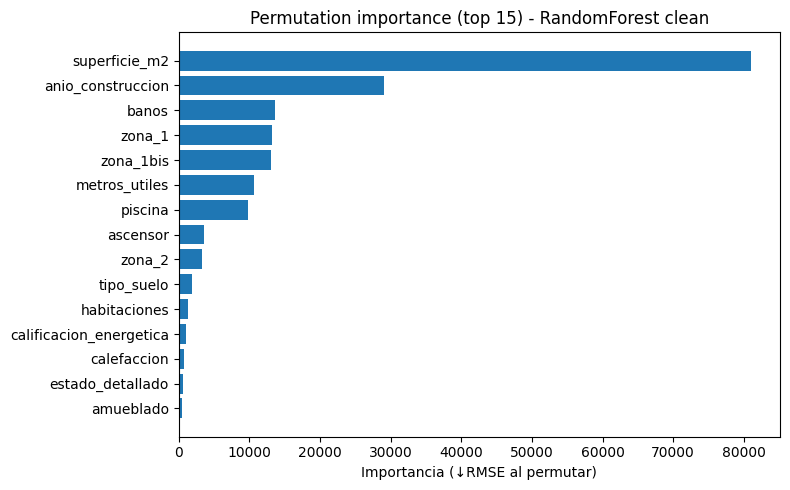

In [59]:
# Visualización rápida de las 15 más importantes
topk = 15
plt.figure(figsize=(8, 5))
plt.barh(imp["feature"].head(topk)[::-1], imp["importance_mean"].head(topk)[::-1])
plt.xlabel("Importancia (↓RMSE al permutar)")
plt.title("Permutation importance (top 15) - RandomForest clean")
plt.tight_layout()
plt.show()


---
## Diagnóstico de residuos

Los supuestos clásicos (linealidad, normalidad, homocedasticidad, independencia) son propios del modelo lineal OLS.
Aquí haremos el diagnóstico sobre el **Ridge (clean)** como aproximación didáctica.


In [83]:
modelos = {
    "Baseline": baseline_pipe,
    "Linear Regression": linear_pipe,
    "Lasso": lasso_pipe,
    "Ridge": ridge_pipe_clean,
    "Random Forest": rf_pipe_clean,
}

residuos_modelos = {}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_c)
    residuos_modelos[nombre] = y_test - y_pred
    #print("Resumen residuos:") 
    #display(pd.Series(residuos_modelos[nombre]).describe())

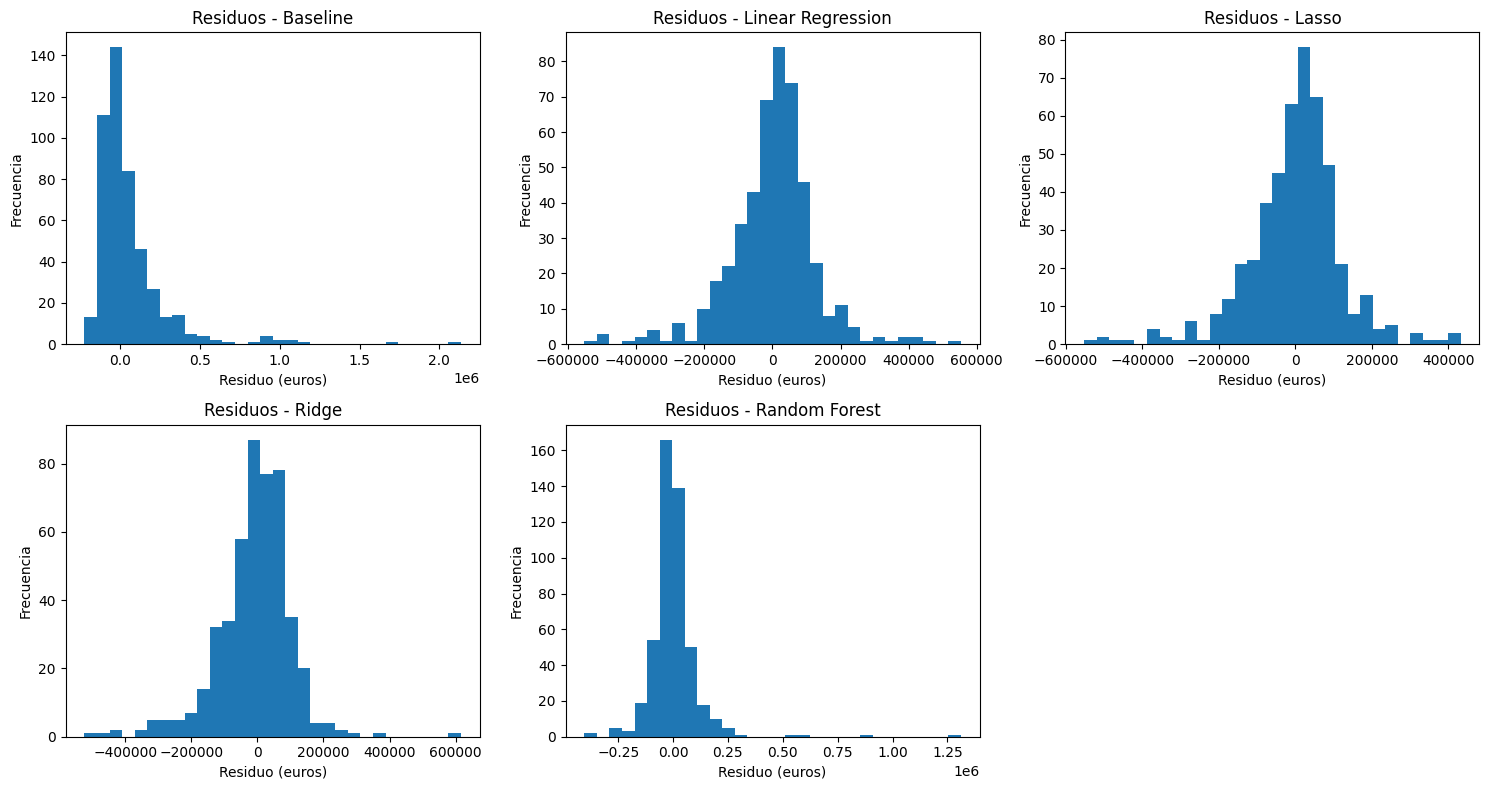

In [84]:
# Grid de histogramas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for ax, (nombre, resid) in zip(axes, residuos_modelos.items()):
    ax.hist(resid, bins=30)
    ax.set_title(f"Residuos - {nombre}")
    ax.set_xlabel("Residuo (euros)")
    ax.set_ylabel("Frecuencia")

# Si sobra alguna celda, la apagamos
for ax in axes[len(residuos_modelos):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Comenta que información puedes extraer de los histogramas de resíduos

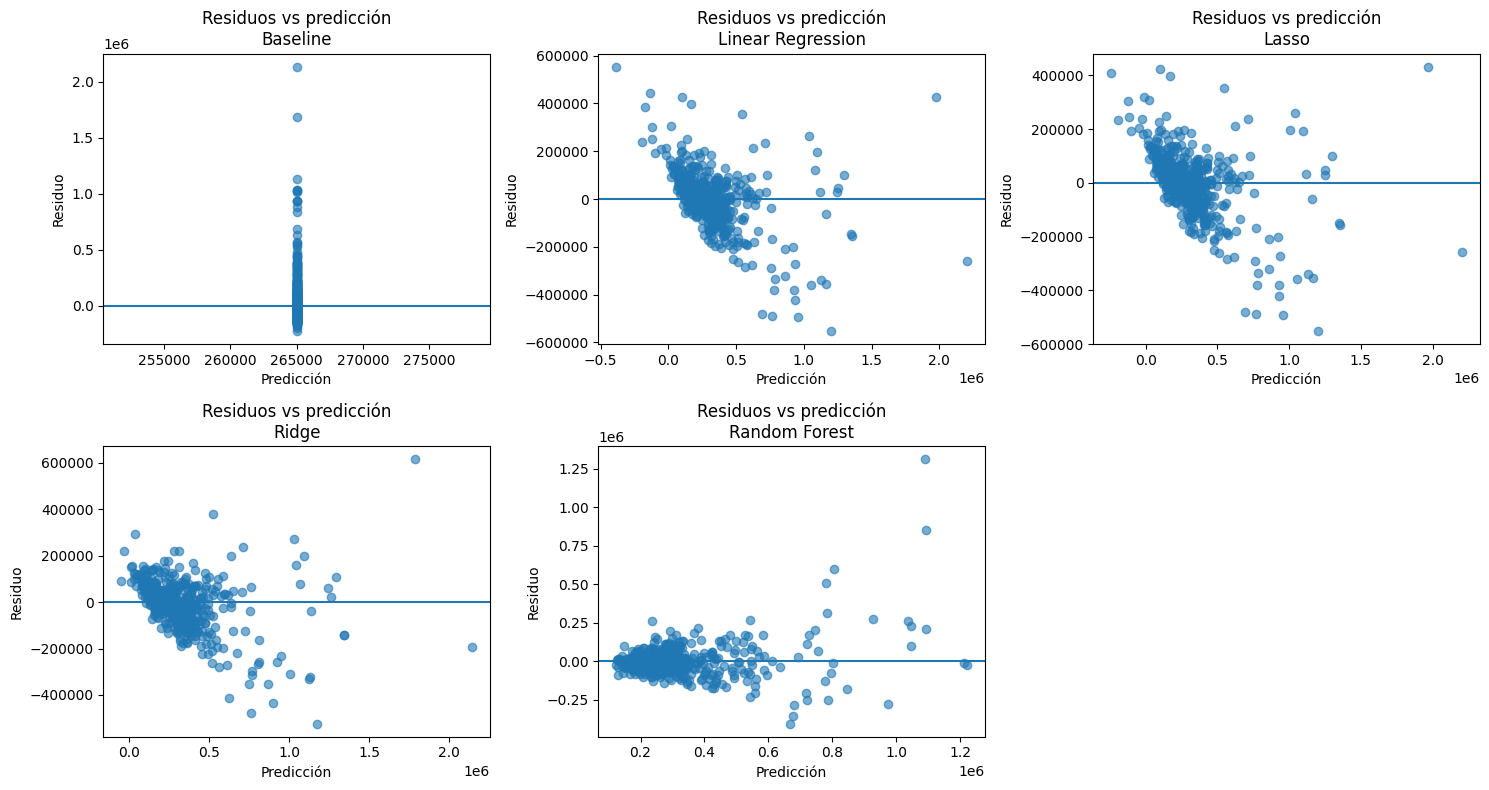

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_c)
    resid = y_test - y_pred

    ax.scatter(y_pred, resid, alpha=0.6)
    ax.axhline(0)
    ax.set_title(f"Residuos vs predicción\n{nombre}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Residuo")

# Apagar ejes sobrantes
for ax in axes[len(modelos):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Comenta qué información puedes extraer de las nubes de resíduos

/var/folders/7y/7qbnckg175x_7bb72vdwtdkw0000gn/T/ipykernel_24580/2237899198.py:18: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(y_pred, resid, 1)


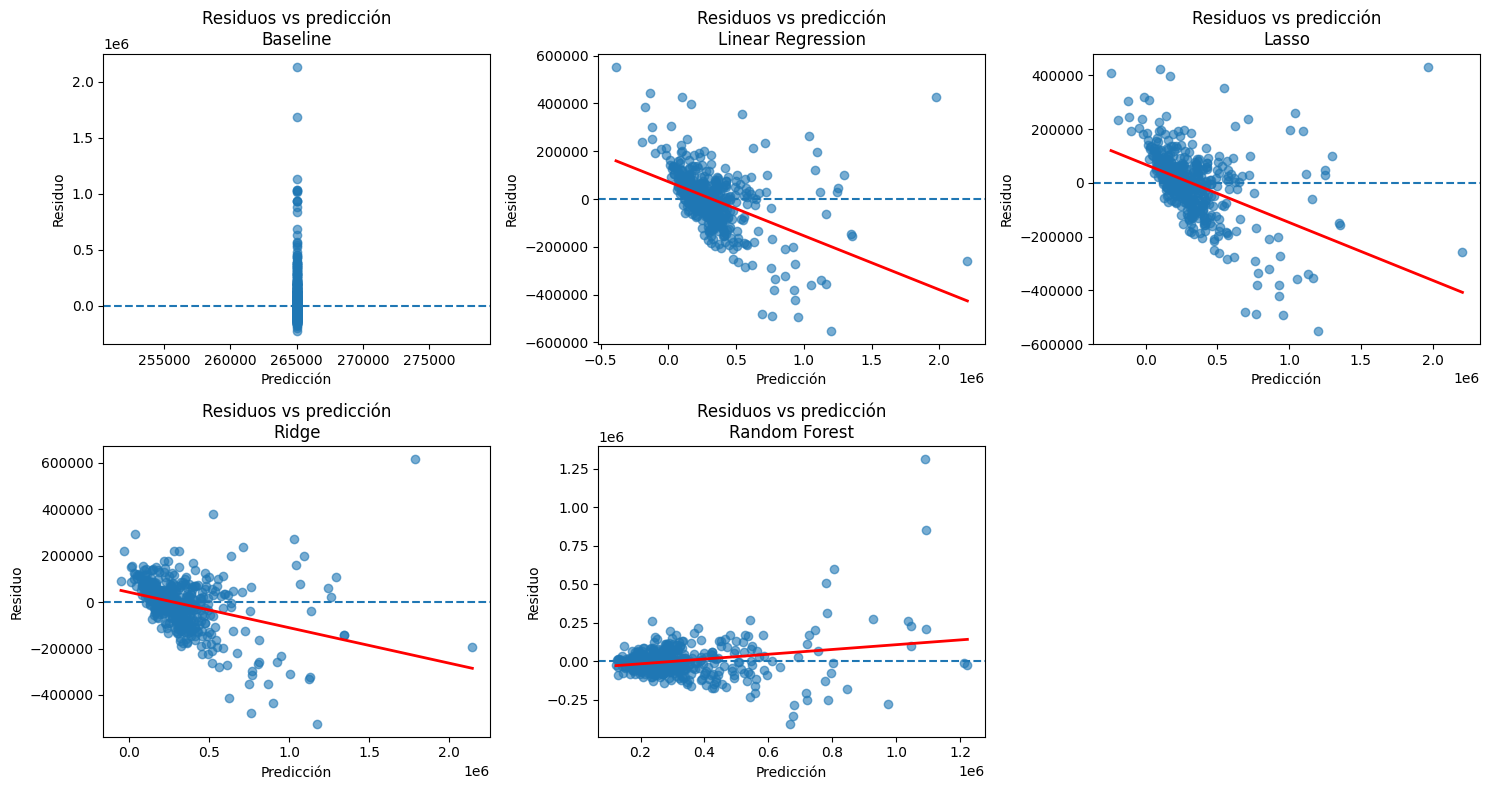

In [107]:
#Finalmente vemos las rectas de regresión
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_c)
    resid = y_test - y_pred

    ax.scatter(y_pred, resid, alpha=0.6)

    # Línea horizontal ideal
    ax.axhline(0, linestyle="--")

    # Recta ajustada sobre residuos vs predicción
    m, b = np.polyfit(y_pred, resid, 1)
    x_line = np.linspace(np.min(y_pred), np.max(y_pred), 200)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, linewidth=2, color="red")

    ax.set_title(f"Residuos vs predicción\n{nombre}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Residuo")

# Apagar ejes sobrantes
for ax in axes[len(modelos):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Comenta que conclusiónes puedes sacar de las rectas de regresión

### Tests

- **Shapiro-Wilk**: normalidad de residuos (ojo: con muchas muestras, detecta desviaciones pequeñas).
- **Breusch-Pagan**: heterocedasticidad.
- **Ramsey RESET**: especificación/linealidad.
- **Durbin-Watson**: autocorrelación (aquí suele ser poco relevante si no hay orden temporal real).

> Nota: estos tests son *orientativos*. Para docencia sirven para “ver señales”, no para dictar sentencias absolutas.


In [63]:
# Para statsmodels necesitamos una matriz X "ya numérica" y con constante.
# Usamos como regresores: predicción y (opcional) una constante, para BP sobre resid.
X_sm = sm.add_constant(y_pred_ridge)

# Shapiro (submuestreamos si fuera enorme)
sample = np.array(resid)
if len(sample) > 1000:
    rng = np.random.default_rng(RANDOM_STATE)
    sample = rng.choice(sample, size=1000, replace=False)

shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, p={shapiro_p:.4g}")

# Breusch-Pagan
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(resid, X_sm)
print(f"Breusch-Pagan: LM p={bp_lm_p:.4g}, F p={bp_f_p:.4g}")

# Durbin-Watson (interpretación limitada aquí)
dw = durbin_watson(resid)
print(f"Durbin-Watson: {dw:.4f}")


Shapiro-Wilk: stat=0.9332, p=9.199e-14
Breusch-Pagan: LM p=2.925e-29, F p=1.486e-33
Durbin-Watson: 1.9449


### Ahora vamos a analizar la interpretación de los residuos

In [88]:
# Interpretación automática de tests sobre residuos
# Asume que ya existen:
#   shapiro_stat, shapiro_p
#   bp_lm, bp_lm_p, bp_f, bp_f_p
#   dw

alpha = 0.05

def interpretar_shapiro(stat, p, alpha=0.05):
    if p > alpha:
        conclusion = "No se rechaza la normalidad de los residuos."
        detalle = "Los residuos son compatibles con una distribución normal."
    else:
        conclusion = "Se rechaza la normalidad de los residuos."
        detalle = "Hay evidencia de que los residuos no siguen una distribución normal."
    return {
        "test": "Shapiro-Wilk",
        "stat": stat,
        "p_value": p,
        "alpha": alpha,
        "conclusion": conclusion,
        "detalle": detalle
    }

def interpretar_breusch_pagan(lm_p, f_p, alpha=0.05):
    # Hipótesis nula: homocedasticidad
    if lm_p > alpha and f_p > alpha:
        conclusion = "No se rechaza la homocedasticidad."
        detalle = "No hay evidencia clara de heterocedasticidad."
    else:
        conclusion = "Se rechaza la homocedasticidad."
        detalle = "Hay evidencia de heterocedasticidad en los residuos."
    return {
        "test": "Breusch-Pagan",
        "lm_p_value": lm_p,
        "f_p_value": f_p,
        "alpha": alpha,
        "conclusion": conclusion,
        "detalle": detalle
    }

def interpretar_durbin_watson(dw):
    # Regla orientativa:
    # ~2   -> sin autocorrelación
    # <2   -> autocorrelación positiva
    # >2   -> autocorrelación negativa
    # cerca de 0 o 4 -> muy fuerte
    if 1.5 <= dw <= 2.5:
        conclusion = "No se aprecia autocorrelación relevante."
        detalle = "El valor está razonablemente cerca de 2."
    elif dw < 1.5:
        conclusion = "Posible autocorrelación positiva."
        detalle = "Cuanto más cerca de 0, más fuerte sería la autocorrelación positiva."
    else:
        conclusion = "Posible autocorrelación negativa."
        detalle = "Cuanto más cerca de 4, más fuerte sería la autocorrelación negativa."
    return {
        "test": "Durbin-Watson",
        "value": dw,
        "conclusion": conclusion,
        "detalle": detalle
    }

# Obtener interpretaciones
res_shapiro = interpretar_shapiro(shapiro_stat, shapiro_p, alpha)
res_bp = interpretar_breusch_pagan(bp_lm_p, bp_f_p, alpha)
res_dw = interpretar_durbin_watson(dw)

# Mostrar resultados
print("Interpretación de los tests:\n")

print(f"[{res_shapiro['test']}]")
print(f"  Estadístico: {res_shapiro['stat']:.4f}")
print(f"  p-valor:     {res_shapiro['p_value']:.6f}")
print(f"  Conclusión:  {res_shapiro['conclusion']}")
print(f"  Detalle:     {res_shapiro['detalle']}\n")

print(f"[{res_bp['test']}]")
print(f"  p-valor LM:  {res_bp['lm_p_value']:.6f}")
print(f"  p-valor F:   {res_bp['f_p_value']:.6f}")
print(f"  Conclusión:  {res_bp['conclusion']}")
print(f"  Detalle:     {res_bp['detalle']}\n")

print(f"[{res_dw['test']}]")
print(f"  Valor:       {res_dw['value']:.4f}")
print(f"  Conclusión:  {res_dw['conclusion']}")
print(f"  Detalle:     {res_dw['detalle']}\n")


Interpretación de los tests:

[Shapiro-Wilk]
  Estadístico: 0.9332
  p-valor:     0.000000
  Conclusión:  Se rechaza la normalidad de los residuos.
  Detalle:     Hay evidencia de que los residuos no siguen una distribución normal.

[Breusch-Pagan]
  p-valor LM:  0.000000
  p-valor F:   0.000000
  Conclusión:  Se rechaza la homocedasticidad.
  Detalle:     Hay evidencia de heterocedasticidad en los residuos.

[Durbin-Watson]
  Valor:       1.9449
  Conclusión:  No se aprecia autocorrelación relevante.
  Detalle:     El valor está razonablemente cerca de 2.



---

## Predicción de un nuevo ejemplo

Creamos una pequeña función para predecir el precio a partir de un diccionario con columnas.

Usaremos el **mejor modelo "clean"** según la tabla anterior (habitualmente RandomForest clean).


In [95]:
# Elegimos el mejor modelo clean por RMSE entre Ridge/RF (puedes cambiarlo)
best_clean_model = rf_pipe_clean  # por defecto

def predecir_precio(ejemplo: dict, model=best_clean_model):
    """ejemplo: dict con algunas columnas del dataset (las que falten se imputan)."""
    X_one = pd.DataFrame([ejemplo])

    # Asegurar que estén las columnas esperadas
    # (ColumnTransformer ignora columnas extra y fallará si faltan columnas que esperaba)
    # Truco: reindexar con columnas de entrenamiento, rellenando con NaN.
    cols = X_train_c.columns
    X_one = X_one.reindex(columns=cols)

    # tipos
    for c in X_one.select_dtypes(include=["bool"]).columns:
        X_one[c] = X_one[c].astype("Int64")

    pred = model.predict(X_one)[0]
    return float(pred)

ejemplo = {
    "superficie_m2": 70,
    "habitaciones": 2,
    "banos": 1,
    "ascensor": 1,
    "parking": 1,
    "calificacion_energetica": "E",
    "zona_1": "Fuenlabrada"   # prueba a poner un municipio/distrito de tu dataset
}

print("Predicción (euros):", round(predecir_precio(ejemplo), 2))


Predicción (euros): 215835.49


---
## Ejercicios propuestos

1. **(Leakage)** Entrena un modelo no lineal (RF) con y sin `precio_por_m2`. Explica por qué cambia tanto.
2. **(Outliers)** Detecta outliers en `precio_num` (IQR o z-score) y reentrena el modelo. ¿Mejora el RMSE?
3. **(Log target)** Compara `Ridge` en precio vs `Ridge` en `log1p(precio)`.
4. **(Validación)** Repite el experimento con validación cruzada (`KFold`) y reporta media y desviación de RMSE.


In [ ]:
##Ejercicio 1RF leaky.


> 🔎 **Lectura recomendada:** si el modelo "leaky" mejora muchísimo, sospecha:  
> 1) ¿La variable está calculada a partir del objetivo?  
> 2) ¿Estás usando información del futuro? (fecha posterior, variables post-venta, etc.)  
> 3) ¿Se cuela un ID que codifica el precio indirectamente?


In [101]:
#Ejercicio 2: Detecta outliers en precio_num (IQR) y reentrena el modelo.
# Comparamos el RMSE antes y después usando, por ejemplo, Ridge.

from sklearn.base import clone
from sklearn.metrics import root_mean_squared_error
import numpy as np
import pandas as pd

...

#Comparación
comparacion_outliers = pd.DataFrame({
    "modelo": ["Ridge original", "Ridge sin outliers"],
    "RMSE": [rmse_original, rmse_sin_outliers]
})

display(comparacion_outliers)

if rmse_sin_outliers < rmse_original:
    print(f"Mejora del RMSE: {rmse_original - rmse_sin_outliers:.2f}")
else:
    print(f"No mejora. Empeora en: {rmse_sin_outliers - rmse_original:.2f}")

Límite inferior: -66162.50
Límite superior: 640937.50
Outliers detectados en train: 165 de 1904
Porcentaje de outliers: 8.67%


,modelo,RMSE
0,Ridge original,111619.567340
1,Ridge sin outliers,150567.948861


No mejora. Empeora en: 38948.38


In [ ]:
#Ejercicio 3: **Variante útil:** entrenar sobre `log(precio)` (reduce sesgo por cola larga). Luego volvemos a euros con `expm1`.

...

ridge_log_model.fit(X_train_c, y_train)
res_ridge_log = evaluar_modelo(ridge_log_model, X_test_c, y_test, nombre="Ridge log1p (clean)")
res_ridge_log


In [98]:
# Ejercicio 4. Validación cruzada rápida con RandomForest clean

...

rmse_cv = -scores["test_rmse"]
mae_cv = -scores["test_mae"]
r2_cv = scores["test_r2"]

print("RMSE CV:", rmse_cv.mean(), "+/-", rmse_cv.std())
print("MAE  CV:", mae_cv.mean(), "+/-", mae_cv.std())
print("R2   CV:", r2_cv.mean(), "+/-", r2_cv.std())

RMSE CV: 145586.72875784463 +/- 30973.80480832278
MAE  CV: 84192.51461420173 +/- 4741.520800027625
R2   CV: 0.7157001866439588 +/- 0.06060308648811359


End of Party

---